# 10 — Fire Weather Index (FWI) Feature Engineering and Experiment

**Project:** Spatio-temporal wildfire activity prediction in Kalimantan  
**Role in pipeline:** Alternative meteorological representation experiment.

### Objective

The main benchmark uses daily raw weather summaries such as temperature, humidity, precipitation, wind speed, wind components, boundary-layer height, and vapour-pressure deficit.

This notebook tests whether the **Canadian Forest Fire Weather Index (FWI) system** provides a more useful compact representation of fire-weather conditions for next-day fire-activity prediction.

### Experiment

```text
Hourly weather
      ↓
local-time conversion
      ↓
daily noon conditions + 24-hour precipitation
      ↓
FFMC, DMC, DC
      ↓
ISI, BUI, FWI
      ↓
merge with fire-history dataset
      ↓
Logistic Regression + Fire History + FWI
      ↓
compare with main 20-feature LR benchmark
```

The FWI experiment is intentionally kept separate from the AQ and spatial-lag experiments.

> **Important:** FWI is a derived fire-weather index, not a direct observation of fire occurrence. The implementation requires sequential state updates and an explicit initialization assumption.


In [3]:
# 1. Imports and project paths

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)

PROJECT_ROOT = Path.cwd().parent
RAW_WEATHER_DIR = PROJECT_ROOT / "data" / "raw" / "kalimantan" / "weather_openmeteo" / "hourly_rich"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "model_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

FIRE_ML_INPUT = PROCESSED_DIR / "karhut_ml_master_kalimantan.csv"

print("Project root:", PROJECT_ROOT)
print("Weather directory:", RAW_WEATHER_DIR)
print("Fire ML input:", FIRE_ML_INPUT)


Project root: c:\Users\Asus\Documents\skripsi-karhut
Weather directory: c:\Users\Asus\Documents\skripsi-karhut\data\raw\kalimantan\weather_openmeteo\hourly_rich
Fire ML input: c:\Users\Asus\Documents\skripsi-karhut\data\processed\karhut_ml_master_kalimantan.csv


In [4]:
# 2. FWI package check

try:
    from cffdrs import cffwis
    print("cffdrs imported successfully.")
except ImportError as exc:
    raise ImportError(
        "The cffdrs package is required. Install it with:\n"
        "pip install git+https://github.com/gagreene/cffdrs.git"
    ) from exc


cffdrs imported successfully.


## 3. Load the hourly weather data

The source weather files are the same Kalimantan `hourly_rich` files used to construct the daily weather features in Notebook 04.

Only the four variables required by the FWI calculation are retained:

- `temperature_2m`
- `relative_humidity_2m`
- `wind_speed_10m`
- `precipitation`


In [5]:
# 3. Discover weather files

weather_files = sorted(RAW_WEATHER_DIR.glob("*.csv"))

print("Number of weather files:", len(weather_files))

if not weather_files:
    raise FileNotFoundError(
        f"No weather CSV files found in {RAW_WEATHER_DIR}"
    )

print("First:", weather_files[0])
print("Last :", weather_files[-1])


Number of weather files: 134
First: c:\Users\Asus\Documents\skripsi-karhut\data\raw\kalimantan\weather_openmeteo\hourly_rich\met_2026-05-01.csv
Last : c:\Users\Asus\Documents\skripsi-karhut\data\raw\kalimantan\weather_openmeteo\hourly_rich\met_2026-09-11.csv


In [6]:
# 4. Load weather files

weather_parts = []

for i, file in enumerate(weather_files, start=1):
    temp = pd.read_csv(file)
    temp["source_file"] = file.name
    weather_parts.append(temp)

    if i % 20 == 0 or i == len(weather_files):
        print(f"Loaded {i}/{len(weather_files)} files")

weather_raw = pd.concat(weather_parts, ignore_index=True)

weather_raw["time_utc"] = pd.to_datetime(
    weather_raw["time_utc"],
    errors="coerce"
)

weather_raw["lat"] = pd.to_numeric(weather_raw["lat"], errors="coerce")
weather_raw["lon"] = pd.to_numeric(weather_raw["lon"], errors="coerce")
weather_raw["value"] = pd.to_numeric(weather_raw["value"], errors="coerce")

print("\nShape:", weather_raw.shape)
print("Date range:", weather_raw["time_utc"].min(), "→", weather_raw["time_utc"].max())
print("Weather cells:", weather_raw[["lat", "lon"]].drop_duplicates().shape[0])


Loaded 20/134 files
Loaded 40/134 files
Loaded 60/134 files
Loaded 80/134 files
Loaded 100/134 files
Loaded 120/134 files
Loaded 134/134 files

Shape: (7836000, 6)
Date range: 2026-05-01 00:00:00 → 2026-09-11 23:00:00
Weather cells: 100


In [7]:
# 5. Validate FWI source variables

FWI_VARS = [
    "temperature_2m",
    "relative_humidity_2m",
    "wind_speed_10m",
    "precipitation"
]

variable_counts = (
    weather_raw["variable"]
    .value_counts()
    .reindex(FWI_VARS)
)

display(variable_counts.to_frame("count"))

if variable_counts.isna().any():
    missing_vars = variable_counts[variable_counts.isna()].index.tolist()
    raise ValueError(f"Missing FWI variables: {missing_vars}")


,count
variable,
temperature_2m,321600
relative_humidity_2m,321600
wind_speed_10m,321600
precipitation,321600


In [8]:
# 6. Long → wide

weather_fwi = (
    weather_raw[
        weather_raw["variable"].isin(FWI_VARS)
    ]
    .pivot_table(
        index=["time_utc", "lat", "lon"],
        columns="variable",
        values="value",
        aggfunc="first"
    )
    .reset_index()
)

print("FWI hourly shape:", weather_fwi.shape)
print("Missing values:")
display(weather_fwi[FWI_VARS].isna().sum().to_frame("missing"))


FWI hourly shape: (321600, 7)
Missing values:


,missing
variable,
temperature_2m,0
relative_humidity_2m,0
wind_speed_10m,0
precipitation,0


## 7. Convert UTC to an approximate local time

FWI daily calculations use local-day observations.

For this development dataset, the weather grid is divided using:

```text
longitude < 114°E  → UTC+7 (WIB)
longitude ≥ 114°E  → UTC+8 (WITA)
```

This is a **longitude-based approximation** used for the grid calculation and should be documented as such rather than presented as an exact administrative time-zone boundary.


In [9]:
# 7. Approximate local-time conversion

weather_fwi["utc_offset"] = np.where(
    weather_fwi["lon"] < 114.0,
    7,
    8
)

weather_fwi["timezone_approx"] = np.where(
    weather_fwi["lon"] < 114.0,
    "WIB",
    "WITA"
)

weather_fwi["time_local"] = (
    weather_fwi["time_utc"]
    + pd.to_timedelta(weather_fwi["utc_offset"], unit="h")
)

weather_fwi["local_date"] = weather_fwi["time_local"].dt.normalize()
weather_fwi["local_hour"] = weather_fwi["time_local"].dt.hour

print(
    weather_fwi[
        ["time_utc", "time_local", "lat", "lon",
         "timezone_approx", "local_date", "local_hour"]
    ].head(10)
)


variable   time_utc          time_local  lat     lon timezone_approx  \
0        2026-05-01 2026-05-01 07:00:00 -4.5  108.00             WIB   
1        2026-05-01 2026-05-01 07:00:00 -4.5  109.25             WIB   
2        2026-05-01 2026-05-01 07:00:00 -4.5  110.50             WIB   
3        2026-05-01 2026-05-01 07:00:00 -4.5  111.75             WIB   
4        2026-05-01 2026-05-01 07:00:00 -4.5  113.00             WIB   
5        2026-05-01 2026-05-01 08:00:00 -4.5  114.25            WITA   
6        2026-05-01 2026-05-01 08:00:00 -4.5  115.50            WITA   
7        2026-05-01 2026-05-01 08:00:00 -4.5  116.75            WITA   
8        2026-05-01 2026-05-01 08:00:00 -4.5  118.00            WITA   
9        2026-05-01 2026-05-01 08:00:00 -4.5  119.25            WITA   

variable local_date  local_hour  
0        2026-05-01           7  
1        2026-05-01           7  
2        2026-05-01           7  
3        2026-05-01           7  
4        2026-05-01           7  
5  

## 8. Construct the 24-hour precipitation amount

The FWI daily inputs require accumulated precipitation over the preceding 24-hour period.

The rolling window is calculated separately for every weather grid cell using the hourly precipitation series.

The first 24-hour period for each grid has no complete history and is therefore excluded from the FWI input.


In [10]:
# 8. 24-hour precipitation

weather_fwi = weather_fwi.sort_values(
    ["lat", "lon", "time_utc"]
).reset_index(drop=True)

weather_fwi["precipitation_24h"] = (
    weather_fwi
    .groupby(["lat", "lon"])["precipitation"]
    .transform(
        lambda x: x.rolling(
            window=24,
            min_periods=24
        ).sum()
    )
)

print("24h precipitation missing:", weather_fwi["precipitation_24h"].isna().sum())


24h precipitation missing: 2300


In [11]:
# 9. Select local-noon daily observations

noon_weather = weather_fwi[
    weather_fwi["local_hour"] == 12
].copy()

print("Noon rows:", len(noon_weather))
print("Unique dates:", noon_weather["local_date"].nunique())
print("Weather grids:", noon_weather[["lat", "lon"]].drop_duplicates().shape[0])

required_daily = [
    "temperature_2m",
    "relative_humidity_2m",
    "wind_speed_10m",
    "precipitation_24h"
]

missing_daily = noon_weather[required_daily].isna().sum()
display(missing_daily.to_frame("missing"))

fwi_input = noon_weather.dropna(
    subset=required_daily
).copy()

print("Complete FWI input rows:", len(fwi_input))
print(
    "FWI input date range:",
    fwi_input["local_date"].min().date(),
    "→",
    fwi_input["local_date"].max().date()
)


Noon rows: 13400
Unique dates: 134
Weather grids: 100


,missing
variable,
temperature_2m,0
relative_humidity_2m,0
wind_speed_10m,0
precipitation_24h,100


Complete FWI input rows: 13300
FWI input date range: 2026-05-02 → 2026-09-11


## 9. FWI initialization

The Canadian FWI system is stateful:

- FFMC depends on the previous day's FFMC.
- DMC depends on the previous day's DMC.
- DC depends on the previous day's DC.
- ISI and BUI are derived from the updated FFMC/DMC/DC.

For this dataset, the development implementation starts each weather-grid sequence with:

```text
FFMC₀ = 85
DMC₀  = 6
DC₀   = 15
```

These are explicit startup assumptions, not observations from the dataset.

A short warm-up period is retained before the ML dataset begins on May 8.


In [12]:
# 10. FWI calculation functions

INITIAL_FFMC = 85.0
INITIAL_DMC = 6.0
INITIAL_DC = 15.0

def calculate_fwi_for_grid(group):
    group = group.sort_values("local_date").reset_index(drop=True).copy()

    ffmc_prev = INITIAL_FFMC
    dmc_prev = INITIAL_DMC
    dc_prev = INITIAL_DC

    rows = []

    for row in group.itertuples(index=False):
        temp = float(row.temperature_2m)
        rh = float(row.relative_humidity_2m)
        wind = float(row.wind_speed_10m)
        precip = float(row.precipitation_24h)

        ffmc = cffwis.dailyFFMC(
            ffmc_prev,
            temp,
            rh,
            wind,
            precip
        )

        dmc = cffwis.dailyDMC(
            dmc_prev,
            temp,
            rh,
            precip,
            row.local_date.month,
            lat=float(row.lat),
            lat_adjust=True
        )

        dc = cffwis.dailyDC(
            dc_prev,
            temp,
            precip,
            row.local_date.month,
            lat=float(row.lat),
            lat_adjust=True
        )

        isi = cffwis.dailyISI(
            wind,
            ffmc,
            fbp_mod=False
        )

        bui = cffwis.dailyBUI(
            dmc,
            dc
        )

        fwi = cffwis.dailyFWI(
            isi,
            bui
        )

        rows.append({
            "date": row.local_date,
            "weather_lat": row.lat,
            "weather_lon": row.lon,
            "ffmc": ffmc,
            "dmc": dmc,
            "dc": dc,
            "isi": isi,
            "bui": bui,
            "fwi": fwi
        })

        ffmc_prev = ffmc
        dmc_prev = dmc
        dc_prev = dc

    return pd.DataFrame(rows)

print("FWI functions ready.")


FWI functions ready.


In [13]:
# 11. Sequential FWI calculation for all weather grids

fwi_parts = []

for (lat, lon), group in fwi_input.groupby(
    ["lat", "lon"],
    sort=True
):
    result = calculate_fwi_for_grid(group)
    fwi_parts.append(result)

fwi_daily = pd.concat(
    fwi_parts,
    ignore_index=True
)

fwi_daily = fwi_daily.sort_values(
    ["weather_lat", "weather_lon", "date"]
).reset_index(drop=True)

print("FWI daily shape:", fwi_daily.shape)
print(
    "FWI date range:",
    fwi_daily["date"].min().date(),
    "→",
    fwi_daily["date"].max().date()
)
print("FWI grids:", fwi_daily[["weather_lat", "weather_lon"]].drop_duplicates().shape[0])
print("Missing FWI values:", fwi_daily[["ffmc", "dmc", "dc", "isi", "bui", "fwi"]].isna().sum().sum())


FWI daily shape: (13300, 9)
FWI date range: 2026-05-02 → 2026-09-11
FWI grids: 100
Missing FWI values: 0


In [14]:
# 12. FWI descriptive statistics

FWI_COLUMNS = ["ffmc", "dmc", "dc", "isi", "bui", "fwi"]

fwi_stats = (
    fwi_daily[FWI_COLUMNS]
    .describe()
    .T
    .round(4)
)

display(fwi_stats)


,count,mean,std,min,25%,50%,75%,max
ffmc,13300.0,71.5043,16.2953,0.0,61.5727,78.3466,83.8544,92.4020
dmc,13300.0,16.2313,22.3847,0.0,2.9213,6.9056,18.8460,153.2771
dc,13300.0,119.1819,143.0308,0.0,15.0805,61.7557,171.7264,695.9357
isi,13300.0,2.7584,2.6045,0.0,0.6854,1.8986,4.2504,13.8684
bui,13300.0,23.2181,31.4756,0.0,3.7872,10.1054,28.0737,197.6984
fwi,13300.0,5.5419,7.8571,0.0,0.2748,1.5962,8.1955,44.8383


In [15]:
# 13. Sanity-check FWI state continuity

continuity_checks = []

for (lat, lon), group in fwi_daily.groupby(
    ["weather_lat", "weather_lon"]
):
    group = group.sort_values("date")

    continuity_checks.append({
        "weather_lat": lat,
        "weather_lon": lon,
        "n_days": len(group),
        "date_min": group["date"].min(),
        "date_max": group["date"].max(),
        "duplicate_dates": group["date"].duplicated().sum()
    })

continuity_df = pd.DataFrame(continuity_checks)

display(continuity_df.head())

if continuity_df["duplicate_dates"].sum() != 0:
    raise ValueError("Duplicate FWI dates found within a weather grid.")


,weather_lat,weather_lon,n_days,date_min,date_max,duplicate_dates
0,-4.5,108.00,133,2026-05-02,2026-09-11,0
1,-4.5,109.25,133,2026-05-02,2026-09-11,0
2,-4.5,110.50,133,2026-05-02,2026-09-11,0
3,-4.5,111.75,133,2026-05-02,2026-09-11,0
4,-4.5,113.00,133,2026-05-02,2026-09-11,0


## 10. Save the reusable FWI dataset

The derived FWI table is saved independently so later analysis does not need to recalculate the stateful FWI sequence.


In [16]:
# 14. Save FWI daily dataset

fwi_output = PROCESSED_DIR / "fwi_daily_kalimantan.csv"

fwi_daily.to_csv(
    fwi_output,
    index=False
)

print("Saved:", fwi_output)


Saved: c:\Users\Asus\Documents\skripsi-karhut\data\processed\fwi_daily_kalimantan.csv


## 11. Merge FWI with the Notebook 04 master dataset

Notebook 04 already contains:

- fire-history features,
- daily raw-weather features,
- AQ candidate features,
- target,
- fire-cell coordinates,
- nearest weather-cell coordinates.

For the FWI experiment, the FWI values are joined through:

```text
date + weather_lat + weather_lon
```

This keeps the same weather-grid mapping used by the main pipeline.


In [17]:
# 15. Load the master ML dataset

if not FIRE_ML_INPUT.exists():
    raise FileNotFoundError(
        f"Notebook 04 master dataset not found: {FIRE_ML_INPUT}"
    )

master = pd.read_csv(FIRE_ML_INPUT)
master["date"] = pd.to_datetime(master["date"])

required_master = [
    "cell_id",
    "date",
    "weather_lat",
    "weather_lon",
    "target_fire_active_t1"
]

missing_master = sorted(set(required_master) - set(master.columns))
if missing_master:
    raise ValueError(f"Missing master columns: {missing_master}")

print("Master shape:", master.shape)
print(
    "Master date range:",
    master["date"].min().date(),
    "→",
    master["date"].max().date()
)


Master shape: (34272, 39)
Master date range: 2026-05-08 → 2026-09-10


In [18]:
# 16. Merge FWI with the ML master dataset

fwi_merge = fwi_daily.copy()
fwi_merge["date"] = pd.to_datetime(fwi_merge["date"])

fwi_keys = ["date", "weather_lat", "weather_lon"]

duplicate_fwi_keys = fwi_merge.duplicated(fwi_keys).sum()
if duplicate_fwi_keys:
    raise ValueError(
        f"Duplicate FWI merge keys found: {duplicate_fwi_keys}"
    )

fwi_dataset = master.merge(
    fwi_merge[
        fwi_keys + FWI_COLUMNS
    ],
    on=fwi_keys,
    how="left",
    validate="many_to_one"
)

print("Merged shape:", fwi_dataset.shape)
print("Missing FWI values:")
display(fwi_dataset[FWI_COLUMNS].isna().sum().to_frame("missing"))


Merged shape: (34272, 45)
Missing FWI values:


,missing
ffmc,0
dmc,0
dc,0
isi,0
bui,0
fwi,0


In [19]:
# 17. Define the FWI experiment features

FIRE_HISTORY_FEATURES = [
    "fire_count_lag1",
    "fire_count_lag3",
    "fire_count_lag7",
    "frp_sum_lag1",
    "frp_sum_lag3",
    "frp_sum_lag7",
    "fire_count_roll3",
    "fire_count_roll7",
    "frp_sum_roll3",
    "frp_sum_roll7"
]

FWI_FEATURES = [
    "ffmc",
    "dmc",
    "dc",
    "isi",
    "bui",
    "fwi"
]

FWI_EXPERIMENT_FEATURES = FIRE_HISTORY_FEATURES + FWI_FEATURES

analysis_df = fwi_dataset.dropna(
    subset=FWI_EXPERIMENT_FEATURES + ["target_fire_active_t1"]
).copy()

print("Experiment rows:", len(analysis_df))
print("Features:", len(FWI_EXPERIMENT_FEATURES))
print("Target positive rate:", analysis_df["target_fire_active_t1"].mean())


Experiment rows: 34272
Features: 16
Target positive rate: 0.18329831932773108


## 12. Temporal evaluation protocol

The FWI experiment uses the **same temporal boundaries** as the main benchmark:

```text
Tuning train: 2026-05-08 → 2026-06-30
Tuning validation: 2026-07-01 → 2026-07-31
Final validation: August 2026
Test: September 2026
```

No information from August or September is used to construct the FWI state itself; FWI is generated sequentially from the weather history available before each date.


In [20]:
# 18. Temporal masks

train_mask = analysis_df["date"] < "2026-08-01"

val_mask = (
    (analysis_df["date"] >= "2026-08-01") &
    (analysis_df["date"] < "2026-09-01")
)

test_mask = analysis_df["date"] >= "2026-09-01"

X_train = analysis_df.loc[train_mask, FWI_EXPERIMENT_FEATURES]
y_train = analysis_df.loc[train_mask, "target_fire_active_t1"].astype(int)

X_val = analysis_df.loc[val_mask, FWI_EXPERIMENT_FEATURES]
y_val = analysis_df.loc[val_mask, "target_fire_active_t1"].astype(int)

X_test = analysis_df.loc[test_mask, FWI_EXPERIMENT_FEATURES]
y_test = analysis_df.loc[test_mask, "target_fire_active_t1"].astype(int)

print("TRAIN:", X_train.shape, "positive rate:", y_train.mean())
print("VALIDATION:", X_val.shape, "positive rate:", y_val.mean())
print("TEST:", X_test.shape, "positive rate:", y_test.mean())


TRAIN: (23120, 16) positive rate: 0.11042387543252595
VALIDATION: (8432, 16) positive rate: 0.3391840607210626
TEST: (2720, 16) positive rate: 0.31948529411764703


In [21]:
# 19. Logistic Regression experiment

lr_fwi = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        )
    )
])

lr_fwi.fit(X_train, y_train)

val_proba = lr_fwi.predict_proba(X_val)[:, 1]

fwi_val_pr_auc = average_precision_score(
    y_val,
    val_proba
)

print(f"LR + Fire History + FWI — Validation PR-AUC: {fwi_val_pr_auc:.6f}")


LR + Fire History + FWI — Validation PR-AUC: 0.895577


In [22]:
# 20. Select an operating threshold on validation

thresholds = np.linspace(0.05, 0.95, 181)

threshold_rows = []

for threshold in thresholds:
    pred = (val_proba >= threshold).astype(int)

    threshold_rows.append({
        "threshold": threshold,
        "precision": precision_score(y_val, pred, zero_division=0),
        "recall": recall_score(y_val, pred, zero_division=0),
        "f1": f1_score(y_val, pred, zero_division=0),
        "accuracy": accuracy_score(y_val, pred)
    })

threshold_df = pd.DataFrame(threshold_rows)

best_threshold_row = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

FWI_THRESHOLD = float(best_threshold_row["threshold"])

print("Validation-selected threshold:", FWI_THRESHOLD)
print(best_threshold_row)


Validation-selected threshold: 0.635
threshold    0.635000
precision    0.788216
recall       0.841958
f1           0.814201
accuracy     0.869663
Name: 117, dtype: float64


In [23]:
# 21. Validation metrics

val_pred = (
    val_proba >= FWI_THRESHOLD
).astype(int)

val_metrics = {
    "Model": "LR + Fire History + FWI",
    "Split": "Validation",
    "PR-AUC": fwi_val_pr_auc,
    "Precision": precision_score(y_val, val_pred, zero_division=0),
    "Recall": recall_score(y_val, val_pred, zero_division=0),
    "F1": f1_score(y_val, val_pred, zero_division=0),
    "Accuracy": accuracy_score(y_val, val_pred),
    "Threshold": FWI_THRESHOLD
}

print(pd.Series(val_metrics).to_string())
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, val_pred))


Model        LR + Fire History + FWI
Split                     Validation
PR-AUC                      0.895577
Precision                   0.788216
Recall                      0.841958
F1                          0.814201
Accuracy                    0.869663
Threshold                      0.635

Confusion Matrix:
[[4925  647]
 [ 452 2408]]


In [24]:
# 22. Test evaluation

test_proba = lr_fwi.predict_proba(X_test)[:, 1]
test_pred = (
    test_proba >= FWI_THRESHOLD
).astype(int)

test_metrics = {
    "Model": "LR + Fire History + FWI",
    "Split": "Test",
    "PR-AUC": average_precision_score(y_test, test_proba),
    "Precision": precision_score(y_test, test_pred, zero_division=0),
    "Recall": recall_score(y_test, test_pred, zero_division=0),
    "F1": f1_score(y_test, test_pred, zero_division=0),
    "Accuracy": accuracy_score(y_test, test_pred),
    "Threshold": FWI_THRESHOLD
}

print(pd.Series(test_metrics).to_string())
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, test_pred))


Model        LR + Fire History + FWI
Split                           Test
PR-AUC                       0.89105
Precision                   0.751992
Recall                      0.868815
F1                          0.806193
Accuracy                    0.866544
Threshold                      0.635

Confusion Matrix:
[[1602  249]
 [ 114  755]]


## 13. Compare FWI with the main benchmark

The main benchmark from Notebook 05 is:

```text
Logistic Regression
+ Fire History (10)
+ Raw Weather (10)
```

The FWI experiment instead uses:

```text
Logistic Regression
+ Fire History (10)
+ FWI (6)
```

The comparison is descriptive and uses the same final validation period. The FWI experiment is **not** treated as a replacement for the main benchmark unless it demonstrates improved predictive performance under the same protocol.


In [25]:
# 23. Benchmark comparison using the established Notebook 05 validation result

MAIN_BENCHMARK_PR_AUC = 0.901149

comparison = pd.DataFrame([
    {
        "Experiment": "LR + Fire History + Raw Weather",
        "Validation PR-AUC": MAIN_BENCHMARK_PR_AUC
    },
    {
        "Experiment": "LR + Fire History + FWI",
        "Validation PR-AUC": fwi_val_pr_auc
    }
])

comparison["Difference_vs_main_benchmark"] = (
    comparison["Validation PR-AUC"] -
    MAIN_BENCHMARK_PR_AUC
)

display(comparison)


,Experiment,Validation PR-AUC,Difference_vs_main_benchmark
0,LR + Fire History + Raw Weather,0.901149,0.000000
1,LR + Fire History + FWI,0.895577,-0.005572


In [26]:
# 24. Correlation diagnostics

correlation_targets = [
    "fire_count_roll7",
    "frp_sum_roll7",
    "fire_count_lag1",
    "frp_sum_lag1"
]

corr_rows = []

for feature in correlation_targets:
    corr_rows.append({
        "feature": feature,
        "pearson_corr_with_fwi": analysis_df[feature].corr(
            analysis_df["fwi"]
        )
    })

corr_df = pd.DataFrame(corr_rows).sort_values(
    "pearson_corr_with_fwi",
    key=lambda s: s.abs(),
    ascending=False
)

display(corr_df)


,feature,pearson_corr_with_fwi
2,fire_count_lag1,0.237990
0,fire_count_roll7,0.234943
1,frp_sum_roll7,0.230326
3,frp_sum_lag1,0.216088


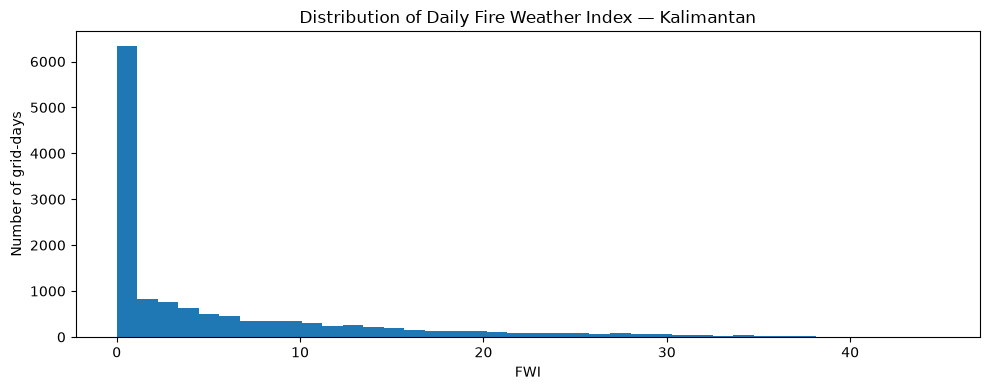

In [27]:
# 25. Plot the FWI distribution

plt.figure(figsize=(10, 4))
plt.hist(fwi_daily["fwi"], bins=40)
plt.xlabel("FWI")
plt.ylabel("Number of grid-days")
plt.title("Distribution of Daily Fire Weather Index — Kalimantan")
plt.tight_layout()
plt.show()


In [28]:
# 26. Save experiment outputs

fwi_val_output = RESULTS_DIR / "fwi_validation_results.csv"
fwi_test_output = RESULTS_DIR / "fwi_test_results.csv"
fwi_corr_output = RESULTS_DIR / "fwi_correlation_diagnostics.csv"
fwi_compare_output = RESULTS_DIR / "fwi_vs_main_benchmark.csv"

pd.DataFrame([val_metrics]).to_csv(
    fwi_val_output,
    index=False
)

pd.DataFrame([test_metrics]).to_csv(
    fwi_test_output,
    index=False
)

corr_df.to_csv(
    fwi_corr_output,
    index=False
)

comparison.to_csv(
    fwi_compare_output,
    index=False
)

print("Saved:")
for path in [
    fwi_val_output,
    fwi_test_output,
    fwi_corr_output,
    fwi_compare_output,
    fwi_output
]:
    print(path)


Saved:
c:\Users\Asus\Documents\skripsi-karhut\model_results\fwi_validation_results.csv
c:\Users\Asus\Documents\skripsi-karhut\model_results\fwi_test_results.csv
c:\Users\Asus\Documents\skripsi-karhut\model_results\fwi_correlation_diagnostics.csv
c:\Users\Asus\Documents\skripsi-karhut\model_results\fwi_vs_main_benchmark.csv
c:\Users\Asus\Documents\skripsi-karhut\data\processed\fwi_daily_kalimantan.csv


## 14. Interpretation

The FWI experiment tests whether a standardized fire-weather index is more useful for this prediction task than the raw daily weather representation.

A lower validation PR-AUC does not mean that FWI is an invalid fire-weather index. It means that, under this dataset, target definition, temporal split, and feature configuration, the tested FWI representation did not provide additional predictive performance over the main benchmark.

Potential reasons should be discussed cautiously. FWI is a derived sequential index and compresses several meteorological variables into a smaller set of state variables. The target in this study is observed FIRMS cell-day fire activity, so the information most useful for this target may not align perfectly with the information emphasized by the FWI system.

Do not use causal language based solely on these predictive results.
